# Schrödinger Bridge Interpolation (Entropic OT View)

The Schrödinger bridge builds the most likely stochastic evolution between fixed marginals under a diffusion prior.
In discrete settings, it is tightly connected to entropic OT couplings:
$$
\gamma^\star = \arg\min_{\gamma \in \Pi(a,b)} \langle C,\gamma\rangle + \varepsilon\,\mathrm{KL}(\gamma).
$$
This notebook visualizes entropic interpolation between 1D marginals.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/schrodinger-bridge") if Path("python/schrodinger-bridge").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Source/target marginals and entropic coupling

We compute an entropic coupling $\gamma$ between two 1D histograms via Sinkhorn iterations.


In [2]:
n = 170
x = np.linspace(0, 1, n)

def normalize(v):
    v = np.maximum(v, 1e-14)
    return v / v.sum()

a = normalize(np.exp(-((x-0.22)/0.07)**2) + 0.8*np.exp(-((x-0.38)/0.04)**2))
b = normalize(np.exp(-((x-0.73)/0.08)**2) + 0.5*np.exp(-((x-0.87)/0.03)**2))
C = (x[:, None]-x[None, :])**2
eps = 0.01

K = np.exp(-C/eps)
u = np.ones_like(a); v = np.ones_like(b)
for _ in range(600):
    u = a/(K@v + 1e-16)
    v = b/(K.T@u + 1e-16)
G = (u[:, None]*K)*v[None, :]
G = G/G.sum()


## Entropic displacement interpolation

Given coupling mass $\gamma_{ij}$ between locations $(x_i, x_j)$, we interpolate particles:
$$
z_{ij}(t) = (1-t)x_i + t x_j,\qquad t\in[0,1].
$$
Aggregating $\gamma_{ij}$ on bins yields intermediate densities.


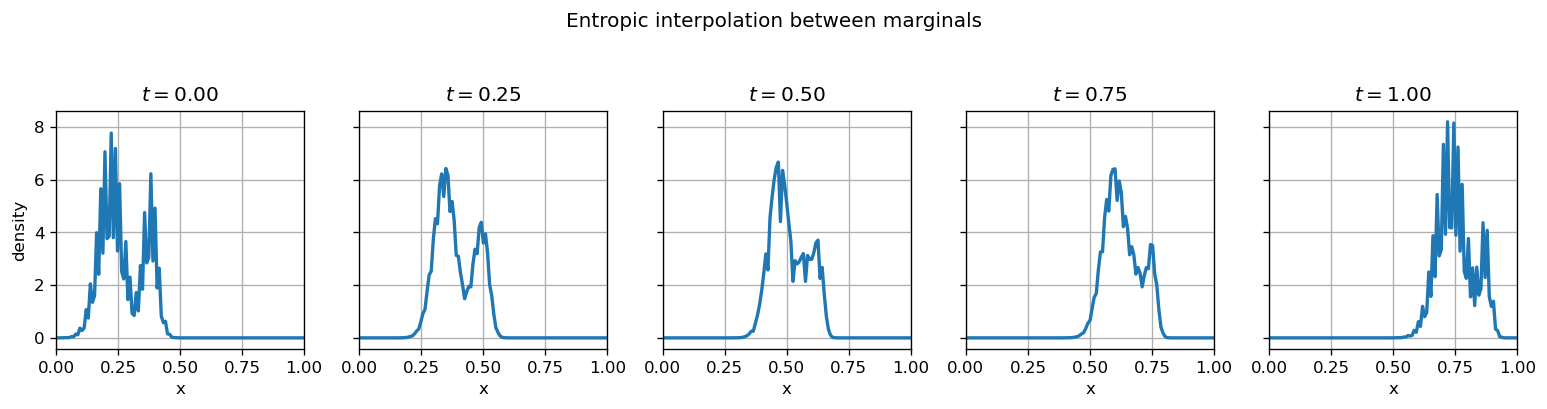

In [3]:
ts = [0.0, 0.25, 0.5, 0.75, 1.0]
bins = np.linspace(0, 1, 120)

I, J = np.nonzero(G > 1e-9)
W = G[I, J]
Xi = x[I]
Xj = x[J]

fig, axes = plt.subplots(1, len(ts), figsize=(13, 3.2), sharey=True)
for ax, t in zip(axes, ts):
    Z = (1-t)*Xi + t*Xj
    hist, edges = np.histogram(Z, bins=bins, weights=W, density=True)
    xc = 0.5*(edges[:-1]+edges[1:])
    ax.plot(xc, hist, lw=2)
    ax.set_title(fr"$t={t:.2f}$")
    ax.set_xlim(0, 1)
    ax.set_xlabel("x")
axes[0].set_ylabel("density")
fig.suptitle("Entropic interpolation between marginals", y=1.05)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- C. Léonard, "A Survey of the Schrödinger Problem and Some of Its Connections with Optimal Transport", DCDS-A, 2014.
- Y. Chen, T. T. Georgiou, M. Pavon, "Optimal Transport over a Linear Dynamical System", IEEE TAC, 2016.
- J.-D. Benamou et al., "Iterative Bregman Projections for Regularized Transportation Problems", SIAM JSC, 2015.
